In [38]:
import pandas as pd
import re
import string
from bs4 import BeautifulSoup

# โหลดข้อมูลจากไฟล์ CSV
file_path = 'job_data_merged_1.csv'
data = pd.read_csv(file_path)

# 1. ตรวจสอบข้อมูลเบื้องต้น
print("ข้อมูลเบื้องต้น:")
print(data.head())  # ดู 5 แถวแรก
print(data.info())  # ดูข้อมูลเกี่ยวกับประเภทของคอลัมน์และข้อมูลที่หายไป

ข้อมูลเบื้องต้น:
   Unnamed: 0          Category Workplace  \
0           0  Business Analyst    Remote   
1           1  Business Analyst    Remote   
2           2  Business Analyst   On-site   
3           3  Business Analyst   On-site   
4           4  Business Analyst    Remote   

                                       Location             Department  \
0                                United Kingdom             Operations   
1             Makati, Metro Manila, Philippines                 Aux HQ   
2  Al-Dajeej, Al Farwaniyah Governorate, Kuwait       PWC Technologies   
3               London, England, United Kingdom  Consultants, Advisory   
4                                United Kingdom             Operations   

        Type  
0  Full time  
1  Full time  
2  Full time  
3  Full time  
4  Full time  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------

In [39]:
# 2. ตรวจสอบข้อมูลที่หายไป
missing_data = data.isnull().sum()
print("\nข้อมูลที่หายไป:")
print(missing_data)


ข้อมูลที่หายไป:
Unnamed: 0      0
Category        0
Workplace      56
Location       68
Department    166
Type          169
dtype: int64


In [47]:
#Clean
def super_clean(text):
    if pd.isna(text):
        return ""
    
    # 1. แปลงเป็นตัวพิมพ์เล็ก (Lowercase)
    text = str(text).lower()
    
    # 2. ลบเครื่องหมายวรรคตอนและสัญลักษณ์พิเศษทั้งหมด (รวมถึง , และ " )
    # แต่เราจะเก็บเครื่องหมาย + และ # ไว้ (เผื่อเจอคำว่า C++, C#)
    text = re.sub(r'[^a-z0-9+#\s]', ' ', text)
    
    # 3. ลบช่องว่างส่วนเกิน (Extra Whitespaces)
    # วิธีนี้จะจัดการทั้งช่องว่างระหว่างคำ, ขึ้นบรรทัดใหม่ และ Tab
    text = " ".join(text.split())
    
    return text

def process_and_save():
    input_file = "job_data_merged_1.csv"
    output_file = "cleaned_job_data.csv"

    if not os.path.exists(input_file):
        print(f"❌ ไม่พบไฟล์ {input_file}")
        return

    # อ่านข้อมูล
    df = pd.read_csv(input_file)
    print("--- เริ่มการ Clean ข้อมูล ---")

    # เลือก Column ที่เราต้องการใช้ (อ้างอิงจากข้อมูลที่คุณส่งมา)
    target_cols = ['Category', 'Workplace', 'Location', 'Department', 'Type']
    
    # สร้าง Column ใหม่สำหรับเก็บผลลัพธ์ที่ Clean แล้ว
    for col in target_cols:
        if col in df.columns:
            # ทำความสะอาดทีละ Column
            df[f'cleaned_{col}'] = df[col].apply(super_clean)
        else:
            # ถ้าไม่มี Column นั้น ให้สร้างเป็นค่าว่างไว้
            df[f'cleaned_{col}'] = ""

    # รวมทุก Column ที่ Clean แล้วเข้าด้วยกันเป็น Column เดียวสำหรับใช้กับ Model
    df['final_features'] = df[[f'cleaned_{col}' for col in target_cols]].agg(' '.join, axis=1)
    
    # ลบช่องว่างส่วนเกินจากการรวม Column อีกรอบ
    df['final_features'] = df['final_features'].apply(lambda x: " ".join(x.split()))

    # บันทึกไฟล์ (เลือกเก็บเฉพาะ Column สำคัญเพื่อความสะอาด)
    cols_to_save = target_cols + ['final_features']
    df[cols_to_save].to_csv(output_file, index=False)

    print(f"✅ Clean สำเร็จ! บันทึกไปที่: {output_file}")
    print("\nตัวอย่างข้อมูลที่ได้ (5 แถวแรก):")
    print(df['final_features'].head())

if __name__ == "__main__":
    process_and_save()

--- เริ่มการ Clean ข้อมูล ---
✅ Clean สำเร็จ! บันทึกไปที่: cleaned_job_data.csv

ตัวอย่างข้อมูลที่ได้ (5 แถวแรก):
0    business analyst remote united kingdom operati...
1    business analyst remote makati metro manila ph...
2    business analyst on site al dajeej al farwaniy...
3    business analyst on site london england united...
4    business analyst remote united kingdom operati...
Name: final_features, dtype: object


In [48]:
# โหลดไฟล์ที่ clean แล้วมาเช็ค
check_df = pd.read_csv("cleaned_job_data.csv")

# 1. เช็คตัวพิมพ์ใหญ่ (ต้องได้ 0)
upper_exists = check_df['final_features'].str.contains(r'[A-Z]').sum()
print(f"จำนวนแถวที่มีตัวพิมพ์ใหญ่: {upper_exists}")

# 2. เช็คเครื่องหมายคอมม่า (ต้องได้ 0)
comma_exists = check_df['final_features'].str.contains(',').sum()
print(f"จำนวนแถวที่มีเครื่องหมายคอมม่า: {comma_exists}")

จำนวนแถวที่มีตัวพิมพ์ใหญ่: 0
จำนวนแถวที่มีเครื่องหมายคอมม่า: 0


In [43]:
# โหลดข้อมูลจากไฟล์ CSV
file_path = 'cleaned_job_data.csv'
data = pd.read_csv(file_path)

# 1. ตรวจสอบข้อมูลเบื้องต้น
print("ข้อมูลเบื้องต้น:")
print(data.head())  # ดู 5 แถวแรก
print(data.info())  # ดูข้อมูลเกี่ยวกับประเภทของคอลัมน์และข้อมูลที่หายไป

ข้อมูลเบื้องต้น:
           Category Workplace                                      Location  \
0  Business Analyst    Remote                                United Kingdom   
1  Business Analyst    Remote             Makati, Metro Manila, Philippines   
2  Business Analyst   On-site  Al-Dajeej, Al Farwaniyah Governorate, Kuwait   
3  Business Analyst   On-site               London, England, United Kingdom   
4  Business Analyst    Remote               London, England, United Kingdom   

              Department           Type  \
0             Operations      Full time   
1                 Aux HQ      Full time   
2       PWC Technologies      Full time   
3  Consultants, Advisory      Full time   
4    Change & Innovation  Not Specified   

                                        cleaned_text  
0         business analyst operations united kingdom  
1  business analyst aux hq makati metro manila ph...  
2  business analyst pwc technologies al dajeej al...  
3  business analyst consultan

        Unnamed: 0
count   798.000000
mean    548.911028
std     317.182481
min       0.000000
25%     268.250000
50%     552.500000
75%     814.750000
max    1094.000000


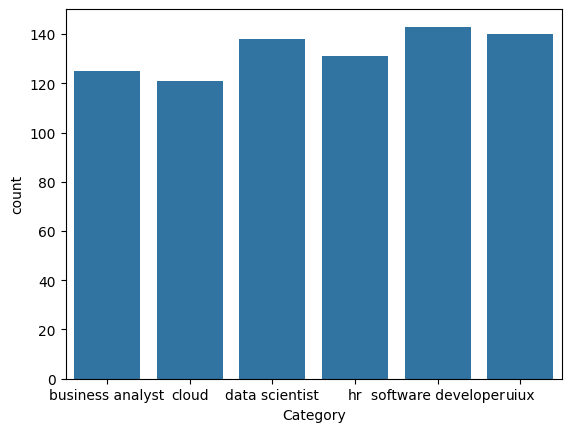

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# สรุปข้อมูลเชิงสถิติ
print(data_cleaned.describe())

# สร้างกราฟแสดงการกระจายของคอลัมน์ต่างๆ
sns.countplot(x='Category', data=data_cleaned)  # แสดงการกระจายของอาชีพ (Category)
plt.show()
